# Mental health in tech: data setup and EDA

The OSMI 2014 "Mental Health in Tech" survey, 1,259 respondents, 27
questions about workplace mental health culture. Cleaning and EDA here,
statistical testing, feature engineering, and modeling with random
forest, gradient boosting, and XGBoost in the following notebooks,
checked against an actual majority-class baseline so "nearly 50%
accurate" means something.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('survey.csv', na_values = ['NA', '', ' ', '.'])
df.shape

(1259, 27)

In [2]:
df.isnull().sum()[df.isnull().sum() > 0]

state              515
self_employed       18
work_interfere     264
comments          1096
dtype: int64

`comments` (1,095 missing) and `state` (515 missing, only meaningful for US respondents anyway) get dropped. `self_employed` (18 missing) gets filled with 'No', the majority class. `work_interfere` (264 missing) is the target, those rows get dropped rather than imputed, since inventing a work-interference level for someone who never answered the question isn't defensible.

In [3]:
df = df.drop(columns = ['comments', 'state'])
df['self_employed'] = df['self_employed'].fillna('No')
df = df.dropna(subset = ['work_interfere']).reset_index(drop = True)
df.shape

(995, 25)

In [4]:
sorted(df.Age.unique())

[np.int64(-1726),
 np.int64(-1),
 np.int64(8),
 np.int64(11),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23),
 np.int64(24),
 np.int64(25),
 np.int64(26),
 np.int64(27),
 np.int64(28),
 np.int64(29),
 np.int64(30),
 np.int64(31),
 np.int64(32),
 np.int64(33),
 np.int64(34),
 np.int64(35),
 np.int64(36),
 np.int64(37),
 np.int64(38),
 np.int64(39),
 np.int64(40),
 np.int64(41),
 np.int64(42),
 np.int64(43),
 np.int64(44),
 np.int64(45),
 np.int64(46),
 np.int64(47),
 np.int64(48),
 np.int64(49),
 np.int64(50),
 np.int64(51),
 np.int64(53),
 np.int64(54),
 np.int64(55),
 np.int64(56),
 np.int64(57),
 np.int64(58),
 np.int64(60),
 np.int64(61),
 np.int64(62),
 np.int64(72),
 np.int64(329),
 np.int64(99999999999)]

Age has a handful of nonsense values (`-1726`, `-29`, `-1`, `5`, `8`,
`11`, `329`, `99999999999`). Replacing them with a single fixed value
like 19 or 56 (the two most common ages) would be an odd choice with no
real justification, why should someone who typed a negative number
actually be 19? Instead, anything outside a plausible working-age range
(15-100) is treated as missing and imputed with the median of the valid
respondents, a smaller, more defensible intervention (only a handful of
rows are affected either way).

In [5]:
valid_age_mask = df.Age.between(15, 100)
median_age = df.loc[valid_age_mask, 'Age'].median()
print(f'{(~valid_age_mask).sum()} invalid ages out of {len(df)}, replaced with median = {median_age}')
df.loc[~valid_age_mask, 'Age'] = median_age

6 invalid ages out of 995, replaced with median = 32.0


In [6]:
df.Gender.value_counts().head(15)

Gender
Male              481
male              157
Female            106
M                  87
female             53
F                  31
m                  23
f                  13
Make                4
Male                3
Cis Male            2
Female              2
Female (trans)      2
Male-ish            1
Trans-female        1
Name: count, dtype: int64

49 distinct spellings for what should be 2-3 categories, consolidated into male/female/trans buckets from explicit spelling lists. A small number of genuinely ambiguous entries (`p`, `A little about you`, `Guy (-ish) ^_^`) get dropped rather than guessed at.

In [7]:
male_terms = ['cis male', 'Cis Male', 'Cis Man', 'm', 'M', 'Mail', 'maile', 'Make', 'Mal',
              'male', 'Male', 'Male-ish', 'Male ', 'Male (CIS)', 'Malr', 'Man', 'msle']
female_terms = ['cis-female/femme', 'Cis Female', 'f', 'F', 'femail', 'Femake', 'female',
                'Female', 'Female ', 'Female (cis)', 'woman', 'Woman']
trans_terms = ['Agender', 'All', 'Androgyne', 'Enby', 'Female (trans)', 'fluid', 'Genderqueer',
               'male leaning androgynous', 'Nah', 'Neuter', 'non-binary',
               'ostensibly male, unsure what that really means', 'queer', 'queer/she/they',
               'something kinda male?', 'Trans-female', 'Trans woman']
ambiguous = ['p', 'Guy (-ish) ^_^', 'A little about you']

def normalize_gender(g):
    if g in male_terms:
        return 'Male'
    if g in female_terms:
        return 'Female'
    if g in trans_terms:
        return 'Trans'
    return 'Ambiguous'

df['Gender'] = df.Gender.apply(normalize_gender)
df = df[df.Gender != 'Ambiguous'].reset_index(drop = True)
df.Gender.value_counts()

Gender
Male      764
Female    211
Trans      17
Name: count, dtype: int64

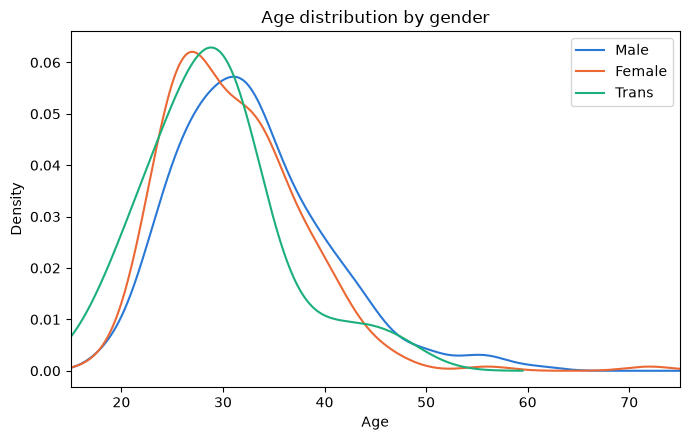

In [8]:
fig, ax = plt.subplots(figsize = (7, 4.5))
for gender, color in zip(['Male', 'Female', 'Trans'], ['#2a78d6', '#eb6834', '#1baf7a']):
    df.loc[df.Gender == gender, 'Age'].plot.kde(ax = ax, label = gender, color = color)
ax.set_xlim(15, 75)
ax.set_xlabel('Age'); ax.legend()
ax.set_title('Age distribution by gender')
plt.tight_layout()
plt.savefig('outputs/age_by_gender.png', dpi = 120)
plt.show()

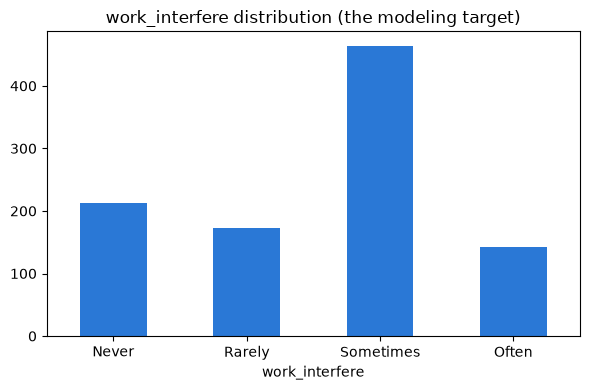

work_interfere
Sometimes    0.467742
Never        0.214718
Rarely       0.174395
Often        0.143145
Name: proportion, dtype: float64

In [9]:
fig, ax = plt.subplots(figsize = (6, 4))
df.work_interfere.value_counts().loc[['Never', 'Rarely', 'Sometimes', 'Often']].plot.bar(ax = ax, color = '#2a78d6')
ax.set_title('work_interfere distribution (the modeling target)')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.savefig('outputs/target_distribution.png', dpi = 120)
plt.show()
df.work_interfere.value_counts(normalize = True)

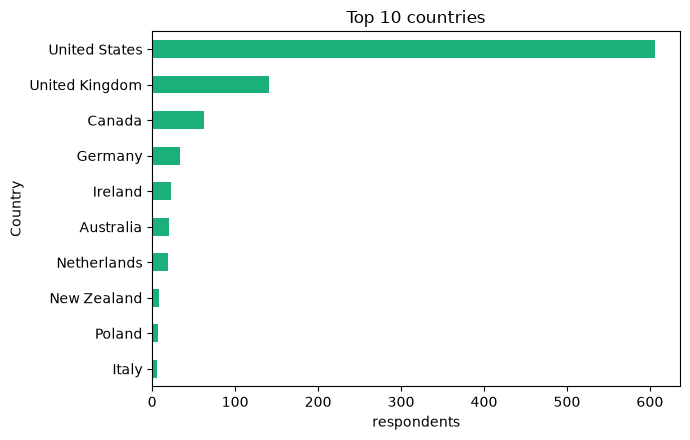

In [10]:
top_countries = df.Country.value_counts().head(10)
fig, ax = plt.subplots(figsize = (7, 4.5))
top_countries.plot.barh(ax = ax, color = '#1baf7a')
ax.invert_yaxis()
ax.set_xlabel('respondents')
ax.set_title('Top 10 countries')
plt.tight_layout()
plt.savefig('outputs/top_countries.png', dpi = 120)
plt.show()

In [11]:
import os, json
os.makedirs('outputs', exist_ok = True)
df.to_pickle('cleaned_mhealth.pkl')

summary = {
    'n_respondents': int(df.shape[0]),
    'n_invalid_ages_fixed': int((~valid_age_mask).sum()),
    'work_interfere_distribution': df.work_interfere.value_counts(normalize = True).to_dict(),
    'top_country': top_countries.index[0],
}
with open('outputs/data_summary.json', 'w') as f:
    json.dump(summary, f, indent = 2)
summary

{'n_respondents': 992,
 'n_invalid_ages_fixed': 6,
 'work_interfere_distribution': {'Sometimes': 0.46774193548387094,
  'Never': 0.21471774193548387,
  'Rarely': 0.1743951612903226,
  'Often': 0.1431451612903226},
 'top_country': 'United States'}